# étoiles binaires spectroscopiques
$\rightarrow$ **analyse de l'étoile12 Boo (données de Philippe)**

## la cible
- 12 Boo est une étoile binaire spectroscopique de la constellation du Bouvier (mV = 4,83)
- La composante primaire (12 Boo Aa) : F8IV
- La composante secondaire (12 Boo Ab) : F8V 
- 12 Boo est une binaire SB2 (double raie) : leur VR/phase montre deux sinusoïdes qui se croisent.
- Quand les étoiles sont "côte à côte" (vu de la Terre), leurs vitesses sont identiques -> un seul pic.
- Quand elles sont à l'opposé sur leur orbite ->  deux pics distincts.

| **Paramètre** | 	Symbole	 | Valeur Pro | 
| -- | --| -- |
| **Période** | $P$ | **9,6045 j** | 9,6045 j (fixé) |
| **Excentricité** | $e$ | **0,192** | **0,178** (Excellent !) |
| **Vitesse systémique** | $\\gamma$ | **\-10,7 km/s** | **\-9,89 km/s** |
| **Amplitude Étoile A** | $K_A$ | **67,2 km/s** | **73,4 km/s** |
| **Amplitude Étoile B** | $K_B$ | **69,3 km/s** | **75,9 km/s** |
| **Argument périastre** | $\\omega$ | **286°** (sec.) | **190°** (primaire) |

--> **pas facile de détecter et de distinguer les deux pics**

## les données 

|||
|---|---|
|OBJECT|	12_Boo  |
|EXPTIME2|	3 x 600 s|
|BSS_ITRP|	16746|
|BSS_VHEL|	0|
|DATE-OBS|	2025-06-16T23:14:30.305 + ...|
|CDELT1| 0.04877652979666891 |                                                 
|BSS_SITE|	Marcenat|
|BSS_INST|	AP115-800 + StarEx2400 + ASI533MM|
|||
             


In [1]:
# import de base
import os, pathlib, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v3 as imageio

import astropy.units as u
from astropy.io import fits
from astropy.nddata import StdDevUncertainty
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time
from astropy.modeling import models
from astropy.stats import mad_std

from specutils import Spectrum
from specutils.fitting import fit_generic_continuum, fit_continuum
from specutils.analysis import centroid, fwhm, snr, snr_derived
from specutils.spectra import SpectralRegion
from specutils.manipulation import extract_region
from specutils.analysis import correlation

from scipy.linalg import svd
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.signal import correlate
from scipy.interpolate import interp1d
from scipy.ndimage import median_filter



In [2]:
# 0. Import du dashboard
%matplotlib widget
from spectro_dashboard import SpectroDashboard

# 1. Afficher le dashboard
db = SpectroDashboard()
db.show()


In [3]:
# paramètres connus (pour aider le modèle)

DISP = 0.0487765        # Dispersion StarEx (A/pixel)
LAMBDA_C = 6562.81       # Longueur d'onde centrale (A)
V_PIX = 299792.458 * (DISP / LAMBDA_C) # VR pour un pixel -> 2.22 km/s)
P = 9.591               # Période orbitale de (jours)
T0_REF = 2460844.2      # Date de référence (JD)
K_A = 68.2              # Amplitude étoile A (km/s)
K_B = -70.8             # Amplitude étoile B (km/s)
E_REF = 0.19            # Excentricité de référence
OMEGA_REF = 190         # Argument du périastre (degrés)
GAMMA_REF = -10.5       # Vitesse systémique (km/s)
OFFSET_INST = 0         # À ajuster selon ta calibration néon

# CONFIGURATION & LOCALISATION (Marcenat)
#Latitude : 45,306° N (environ 45° 18' 25'' N)
#Longitude : 2,828° E (environ 2° 49' 36'' E) 

location = EarthLocation(lat=45.306*u.deg, lon=-2.828*u.deg, height=1000*u.m)   
target = SkyCoord.from_name('12 Boo')

# chargement des spectres --> data_list[] et création du GIF animé
files_path = "data/12Boo/_12_boo_202506*.fits"

# plage de recherche et de comparaison avec le template
region_travail = SpectralRegion(6490*u.AA, 6700*u.AA) 
#region_travail = SpectralRegion(6550*u.AA, 6700*u.AA)

# raies générées du spectre synthétique (Fe, Ni, etc...)
synth_lines = [
    #6493.78, 6494.98, 6499.48, #, 6518.37, 6533.93, # Zone bleue
    6456.38, 6481.87, 6493.78, 6494.98, 6499.48,  6518.37, 6517.07, 6546.24,  # Zone bleue
    6562.81,                                     # H alpha
    6633.75, 6643.63, 6663.44, 6678.00, 6696.32  # Zone rouge
]



# chargement des données

In [4]:

files = sorted(glob.glob(files_path))
data_list = []
images = []
temp_file = 'images/temp.png'
gif_file = 'images/12boo_animation.gif'


for f in files:
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        spec = Spectrum.read(f)
        
        # Extraction et normalisation 
        spec_sub = extract_region(spec, region_travail)
        #new_flux = (spec_sub.flux.value - np.median(spec_sub.flux.value)) * u.dimensionless_unscaled
        
        #spec_final = Spectrum(flux=new_flux, spectral_axis=spec_sub.spectral_axis)
        spec_final = Spectrum(flux=spec_sub.flux, spectral_axis=spec_sub.spectral_axis)
        jd = float(spec.meta['header']['JD-OBS'])
        data_list.append({'jd': jd, 'spec': spec_final})

        """
        # Création du graphique animé
        plt.figure()
        plt.plot(spec.spectral_axis, spec.flux)
        plt.title(spec.meta['header']['DATE-OBS'])
        plt.ylim(0.3, 1.1)
        plt.xlim(6515, 6700)
        plt.xlabel("Longueur d'onde")
        plt.ylabel("Flux")
        #plt.axvline(x=4861, color='red', linestyle='--', linewidth=1, label='Hbeta')
        plt.legend()
        
        # Sauvegarde temporaire
        plt.savefig(temp_file)
        plt.close()
        
        # Ajout à la liste d'images
        images.append(imageio.imread(temp_file))
        """
        
# Création du GIF
#os.remove(temp_file)
#imageio.imwrite(gif_file, images, duration=500, format='GIF', loop=0)   

#data_list
#[spec['spec'] for spec in data_list]


# génération du 'template'

In [53]:

def generate_synthetic_mask(wavelengths, lines):
    mask = np.ones_like(wavelengths)
        
    for l in lines:
        # On trouve l'index le plus proche et on met 1.0 (un seul pixel)
        #idx = np.abs(wavelengths - l).argmin()
        #mask[idx] = 0.0
        # Ajout des raies (gaussiennes inversées)
        mask -= 0.3 * np.exp(-0.5 * ((wavelengths - l) / 0.1)**2)
        
    return mask
    
def load_template(fits_path, my_wavelengths):
    spec = Spectrum.read(fits_path)
    #data = np.array(spec.flux.value, dtype=np.float64).flatten()
    data = np.array(spec.flux.value, dtype=np.float64)
        
    # Nettoyage des NaNs 
    #data = np.nan_to_num(data, nan=np.nanmedian(data))

    # --- RECONSTRUCTION AXE X ---
    hdr = spec.meta['header']
    # On force la dispersion linéaire
    x_pro = hdr['CRVAL1'] + np.arange(len(data)) * hdr['CDELT1']

    # --- INTERPOLATION ---
    f_interp = interp1d(x_pro, data, bounds_error=False, fill_value=0)
    template_resampled = f_interp(my_wavelengths)
    
    # On supprime H-alpha du template pour ne garder que les raies fines (métalliques)
    #mask_sans_halpha = template_resampled.copy()
    #mask_sans_halpha[(my_wavelengths > 6545) & (my_wavelengths < 6580)] = 0
    
    #print(f"Somme finale DATA_SIGNAL: {np.nansum(data_norm):.2f}")
    return (template_resampled)

--> Affichage du spectre F8IV : dispersion=0.0500 Å/px


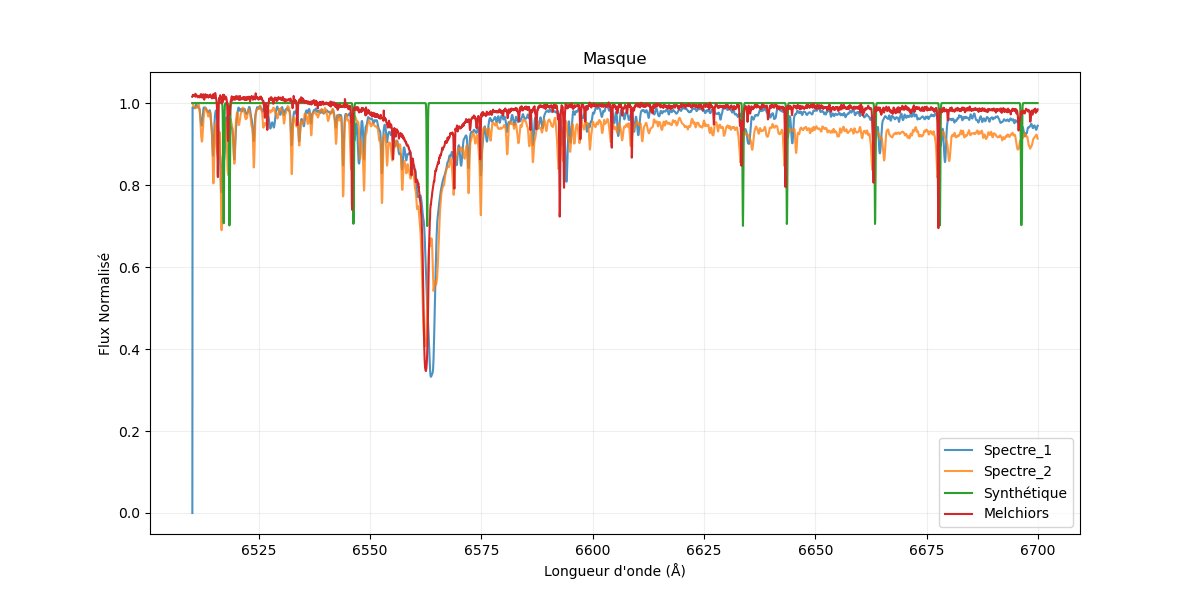

In [55]:

spec_name = "data/12Boo/F8IV_melchiors_417802.fits"
spec = Spectrum.read(spec_name)
db.show_spectrum(spec.spectral_axis, spec.flux, label='F8IV')


# On récupère les données de deux spectres
entry_test = data_list[6]
wave_obs = entry_test['spec'].wavelength.value
flux_obs = entry_test['spec'].flux.value

melchiors_flux = load_template('data/12Boo/F8IV_melchiors_417802.fits', wave_obs)
mask_flux = generate_synthetic_mask(wave_obs, synth_lines)

# On vérifie visuellement que le masque permet de repérer des raies du spectres NON TELLURIQUES !
plt.figure(figsize=(12, 6))
plt.plot(data_list[3]['spec'].wavelength.value, data_list[3]['spec'].flux.value / np.max(data_list[3]['spec'].flux.value), label='Spectre_1', alpha=0.8)
plt.plot(data_list[6]['spec'].wavelength.value, data_list[6]['spec'].flux.value / np.max(data_list[6]['spec'].flux.value), label='Spectre_2', alpha=0.8)
plt.plot(wave_obs, mask_flux, label='Synthétique', lw=1.5) #, ls='--')
plt.plot(wave_obs, melchiors_flux+0.2, label='Melchiors', lw=1.5) #, ls='--')

plt.title(f"Masque")
plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux Normalisé")
plt.legend()
#plt.xlim(6450, 6700)
#plt.ylim(0.4, 1.1)
plt.grid(alpha=0.2)
plt.show()

# analyse - méthode BF


In [56]:
def get_barycentric_correction(jd_utc):
    """Correction de la vitesse de la Terre (Rennes -> 12 Boo)"""
    t = Time(jd_utc, format='jd', scale='utc')
    vcorr = target.radial_velocity_correction(kind='barycentric', obstime=t, location=location)
    return vcorr.to(u.km / u.s)

def compute_broadening_function(observed_flux, template_flux, vel_width=150):
    """
    Calcule la Broadening Function (BF) par Décomposition en Valeurs Singulières (SVD).
    
    Args:
        observed_flux: Spectre de l'étoile (normalisé)
        template_flux: Masque synthétique (normalisé)
        vel_width: Largeur de la fenêtre de recherche en pixels
        
    Returns:
        v_axis: Axe des vitesses en km/s
        bf: Intensité de la BF
    """
    # Synchronisation des tailles et centrage
    n = min(len(observed_flux), len(template_flux))
    o = observed_flux[:n] - np.mean(observed_flux[:n])
    t = template_flux[:n] - np.mean(template_flux[:n])
    
    # Construction de la matrice de design (M)
    m = 2 * vel_width + 1
    M = np.zeros((n, m))
    for i in range(m):
        M[:, i] = np.roll(t, i - vel_width)
    
    # Résolution SVD et filtrage du bruit
    U, S, Vh = svd(M, full_matrices=False)
    S_inv = np.where(S > 0.05 * np.max(S), 1/S, 0) # Seuil de troncature
    
    # Reconstruction
    bf = Vh.T @ np.diag(S_inv) @ U.T @ o
    v_axis = (np.arange(m) - vel_width) * V_PIX
    
    return v_axis, bf

# =============================================================================
# 3. MODÉLISATION ORBITALE
# =============================================================================

def kepler_model(phase, K, e, omega, gamma):
    w_rad = np.radians(omega)
    # Approximation de l'équation de Kepler pour le tri
    v = K * (np.cos(2 * np.pi * phase + w_rad) + e * np.cos(w_rad)) + gamma
    return v

def calculate_masses(K_A, K_B, period_days, eccentricity):
    # Constantes
    G_const = 6.67430e-11
    day_to_sec = 86400
    msun = 1.98847e30
    
    # Conversion en SI (m/s et secondes)
    P_sec = period_days * day_to_sec
    ka_ms = abs(K_A) * 1000
    kb_ms = abs(K_B) * 1000
    
    # Calcul du facteur commun
    factor = (P_sec / (2 * np.pi * G_const)) * (1 - eccentricity**2)**(1.5)
    
    m_a_sin3i = factor * (ka_ms + kb_ms)**2 * kb_ms
    m_b_sin3i = factor * (ka_ms + kb_ms)**2 * ka_ms
    
    # Conversion en masses solaires
    return m_a_sin3i / msun, m_b_sin3i / msun

# --- FONCTION DE FIT AVEC BORNES ---
def fit_orbital_elements_strict(ph, v_obs, is_star_b=False):
    # Initialisation proche de la réalité physique de 12 Boo
    # [K, e, omega, gamma]
    p0 = [70 if not is_star_b else -70, 0.19, 190, -11]
    
    # Bornes pour forcer la solution physique
    if not is_star_b:
        low = [50, 0.10, 160, -25]
        high = [90, 0.28, 220, 5]
    else:
        low = [-90, 0.10, 160, -25]
        high = [-50, 0.28, 220, 5]
        
    popt, _ = curve_fit(kepler_model, ph, v_obs, p0=p0, bounds=(low, high))
    return popt




JD           | VR_A (km/s)  | VR_B (km/s) 
----------------------------------------
2460843.46841 |        nan|      62.85
2460844.43400 |     -93.23|      73.88
2460845.40259 |     -79.97|      60.40
2460846.40154 |     -19.97|       2.32
2460847.40213 |       6.62|     -40.17
2460848.39672 |      44.36|     -73.73
2460849.41439 |      44.19|     -76.13
2460850.39917 |      -2.71|     -49.50
2460851.37702 |     -36.21|      23.95
2460853.40556 |    -103.34|      81.59
2460854.42253 |     -78.96|      63.64
2460855.39118 |     -38.90|      48.00
2460856.40122 |      16.69|     -45.69


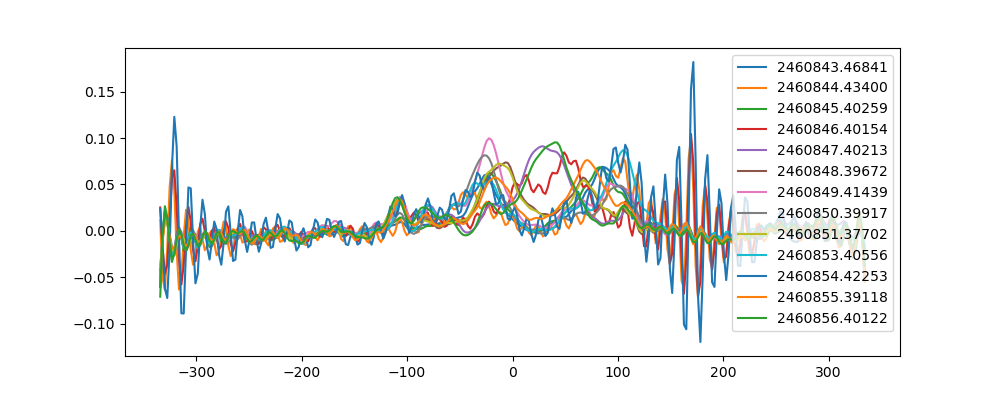

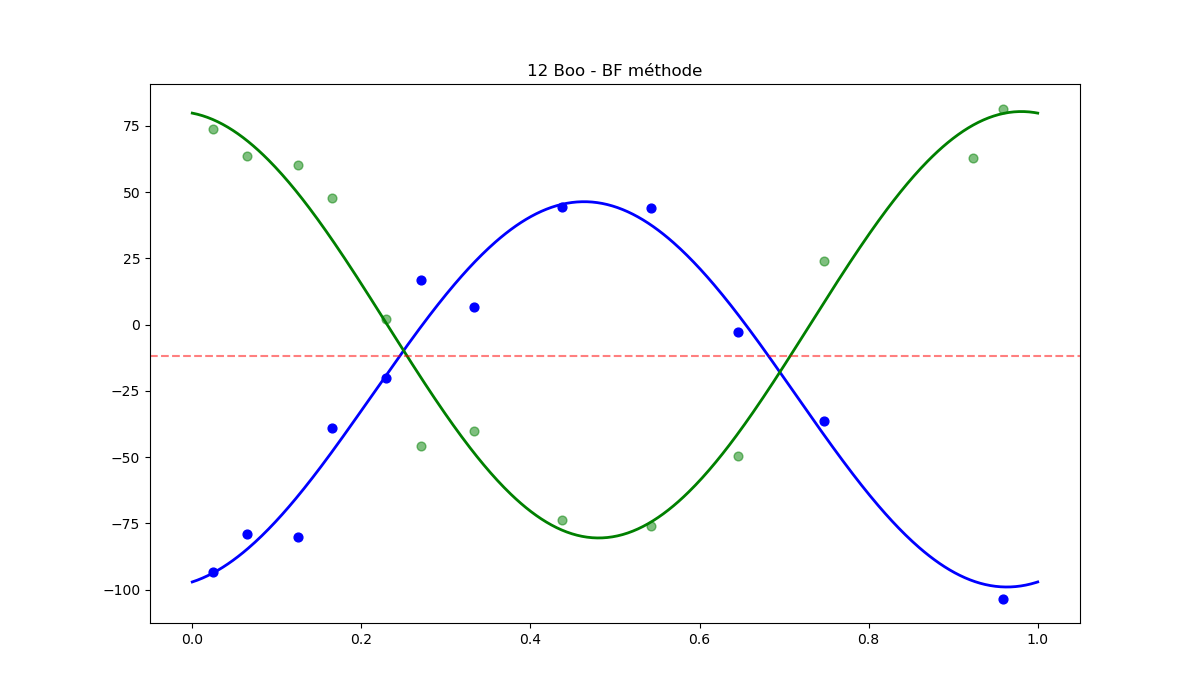

------------------------------
PARAMÈTRES MESURÉS :
Gamma : -11.65 km/s
e     : 0.207
Argument du périastre (w)  : 193.2 °
K_A   : 72.71 km/s
K_B   : 80.47 km/s
------------------------------
MASSES :
M_A sin3i : 1.760 M_sol
M_B sin3i : 1.590 M_sol
------------------------------


In [66]:
# ANALYSE BF

results_A, results_B, phases = [], [], []
print(f"\n{'JD':<12} | {'VR_A (km/s)':<12} | {'VR_B (km/s)':<12}")
print("-" * 40)

# Création d'une figure de diagnostic des BF
plt.figure(figsize=(10, 4))

for entry in data_list:
    # --- A. Préparation du spectre ---
    wave = entry['spec'].wavelength.value
    flux_raw = entry['spec'].flux.value
    
    # Normalisation : on force le continuum à 1.0 (très important !)
    flux_norm = flux_raw / np.percentile(flux_raw, 95)
    obs_flux = flux_norm - np.mean(flux_norm) # Centrage pour la SVD
    obs_flux = 1.0 - obs_flux
    
    # Masque correspondant
    mask_flux = 1.0 - generate_synthetic_mask(wave, synth_lines)
    #mask_flux = 1.0 - load_template('data/12Boo/F8IV_melchiors_417802.fits', wave)
    
    # --- B. Calcul de la BF (SVD) ---
    v_axis, bf = compute_broadening_function(obs_flux, mask_flux)
    
    v_bary = get_barycentric_correction(entry['jd']).value
    plt.plot(v_axis, bf, label=f"{entry['jd']:.5f}")
    
    # Cibles théoriques
    ph = ((entry['jd'] - T0_REF) % P) / P
    v_target_a = kepler_model(ph, K_A, E_REF, OMEGA_REF, GAMMA_REF)
    v_target_b = kepler_model(ph, K_B, E_REF, OMEGA_REF, GAMMA_REF)
    
    # --- C. Détection ---
    peaks, _ = find_peaks(bf) #, height=np.max(bf)*0.25, distance=10)
    #peaks, _ = find_peaks(bf, height=np.max(bf)*0.15, distance=10)
    v_mesures = v_axis[peaks] + v_bary + OFFSET_INST
    
    va, vb = np.nan, np.nan
    if len(v_mesures) > 0:
        # 1. On cherche le pic le plus proche de la courbe A
        idx_a = np.argmin(np.abs(v_mesures - v_target_a))
        if np.abs(v_mesures[idx_a] - v_target_a) < 30:
            va = v_mesures[idx_a]
            # On retire ce pic pour ne pas le donner aussi à B
            v_restants = np.delete(v_mesures, idx_a)
        else:
            v_restants = v_mesures

        # 2. On cherche le candidat pour B parmi les restants
        if len(v_restants) > 0:
            idx_b = np.argmin(np.abs(v_restants - v_target_b))
            if np.abs(v_restants[idx_b] - v_target_b) < 30:
                vb = v_restants[idx_b]
    
    print(f"{entry['jd']:.5f} | {va:10.2f}| {vb:10.2f}")


    results_A.append(va)
    results_B.append(vb)
    phases.append(ph)

plt.legend()
plt.show()

# =============================================================================
# 5. FIT ET CALCUL DES PARAMÈTRES (VERSION SÉCURISÉE)
# =============================================================================

# Conversion propre en tableaux numpy
phases_np = np.array(phases)
results_A_np = np.array(results_A)
results_B_np = np.array(results_B)

# Masques pour ignorer les points perdus (NaN)
mask_a = ~np.isnan(results_A_np)
mask_b = ~np.isnan(results_B_np)


# Calcul effectif
res_A = fit_orbital_elements_strict(phases_np[mask_a], results_A_np[mask_a], is_star_b=False)
res_B = fit_orbital_elements_strict(phases_np[mask_b], results_B_np[mask_b], is_star_b=True)

# Extraction
final_ka = res_A[0]
final_kb = res_B[0]
final_e = res_A[1]      # L'excentricité est la même pour les deux, on prend celle de A
final_w = res_A[2]
final_gamma = res_A[3]

# =============================================================================
# 6. AFFICHAGE DES RÉSULTATS ET GRAPHIQUE
# =============================================================================
phi_plot = np.linspace(0, 1, 500)
v1_plot = kepler_model(phi_plot, *res_A)
v2_plot = kepler_model(phi_plot, *res_B)

plt.figure(figsize=(12, 7))
plt.plot(phi_plot, v1_plot, 'b-', lw=2) #, label=f'Fit A (e={final_e:.3f})')
plt.plot(phi_plot, v2_plot, 'g-', lw=2) #, label=f'Fit B (K={abs(final_kb):.1f})')
plt.axhline(final_gamma, color='red', ls='--', alpha=0.5)
plt.scatter(phases_np[mask_a], results_A_np[mask_a], color='blue', s=40)
plt.scatter(phases_np[mask_b], results_B_np[mask_b], color='green', s=40, alpha=0.5)
plt.title("12 Boo - BF méthode")
plt.show()

# Calcul des masses 
ma_final, mb_final = calculate_masses(final_ka, final_kb, P, final_e)

print("-" * 30)
print(f"PARAMÈTRES MESURÉS :")
print(f"Gamma : {final_gamma:.2f} km/s")
print(f"e     : {final_e:.3f}")
print(f"Argument du périastre (w)  : {final_w:.1f} °")
print(f"K_A   : {final_ka:.2f} km/s")
print(f"K_B   : {abs(final_kb):.2f} km/s")
print("-" * 30)
print(f"MASSES :")
print(f"M_A sin3i : {ma_final:.3f} M_sol")
print(f"M_B sin3i : {mb_final:.3f} M_sol")
print("-" * 30)


# analyse - méthode CCF


JD           | VR_Abs (km/s)
----------------------------------------
2460843.46841 |      64.39
2460844.43400 |      79.77
2460845.40259 |      60.50
2460846.40154 |      30.91
2460847.40213 |       6.94
2460848.39672 |     -28.70
2460849.41439 |     -46.25
2460850.39917 |     -52.23
2460851.37702 |     -31.14
2460853.40556 |      79.29
2460854.42253 |      76.74
2460855.39118 |      47.54
2460856.40122 |      10.52


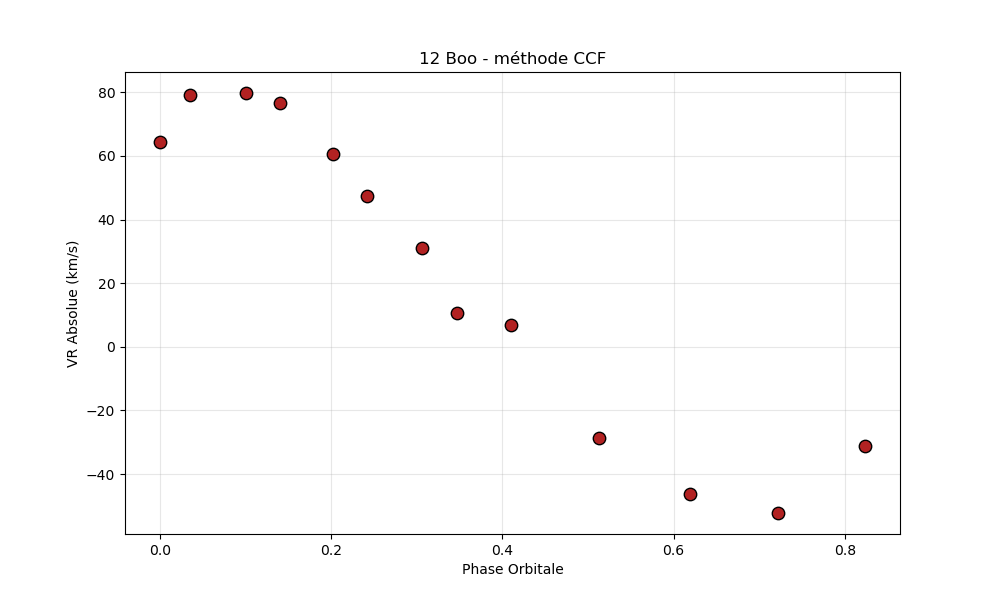

In [70]:
def find_precise_peak(lag, corr):
    """Ajuste une parabole sur le sommet pour une précision sub-pixel"""
    i_max = np.argmax(corr)
    if i_max <= 0 or i_max >= len(corr) - 1:
        return lag[i_max].value
    x = lag[i_max-1 : i_max+2].value
    y = corr[i_max-1 : i_max+2]
    f = np.polyfit(x, y, 2)
    return -f[1] / (2 * f[0])

wave_obs = data_list[0]['spec'].spectral_axis.value

flux_model = generate_synthetic_mask(wave_obs, synth_lines)
tspec_model = Spectrum(flux=flux_model * u.dimensionless_unscaled,
                       spectral_axis=wave_obs * u.AA)


# ---------------------------------------------------------
results = []
print(f"\n{'JD':<12} | {'VR_Abs (km/s)':<12}")
print("-" * 40)


for i, entry in enumerate(data_list):
    
    # On normalise et on retire la moyenne (pour que le continuum soit à 0)
    obs_flux = entry['spec'].flux.value
    obs_flux = obs_flux / np.percentile(obs_flux, 95) - 1.0 
    
    spec_to_corr = Spectrum(flux=obs_flux * u.dimensionless_unscaled,
                            spectral_axis=entry['spec'].spectral_axis)
    
    # Corrélation avec le masque théorique
    #corr, lag = correlation.template_correlate(spec_to_corr, tspec_model)
    corr, lag = correlation.template_correlate(1.0 - entry['spec'], 1.0 - tspec_model)
    #print(f"Décalage min/max du lag : {lag.min()} / {lag.max()}")
    
    v_rel = find_precise_peak(lag, corr)
    v_bary = get_barycentric_correction(entry['jd']).value
    vr_abs = v_rel + v_bary
    
    results.append({'jd': entry['jd'], 'vr': vr_abs})
    print(f"{entry['jd']:.5f} | {vr_abs:10.2f}")

# 6. GRAPHIQUE FINAL (COURBE DE PHASE)
# ---------------------------------------------------------
jd_arr = np.array([r['jd'] for r in results])
vr_arr = np.array([r['vr'] for r in results])

P = 9.6045 
T0 = jd_arr[0]
phases = ((jd_arr - T0) % P) / P

plt.figure(figsize=(10, 6))
plt.scatter(phases, vr_arr, color='firebrick', s=80, edgecolors='k', zorder=3)
#plt.axhline(-10.5, color='gray', linestyle='--', label='Vitesse systémique')
plt.title("12 Boo - méthode CCF")
plt.xlabel("Phase Orbitale")
plt.ylabel("VR Absolue (km/s)")
plt.grid(alpha=0.3)
plt.show()


# tests avec BinaryStarSolve

In [71]:

# first value being the time in Reduced Julian Date (RJD), 
# the second being the radial velocity of the primary star in km/s, 
# the third being the radial velocity of the secondary star in km/s, 
# and the fourth and fifth (optional) values being the respective weights of the primary and second star's radial velocities.

output_ccf = 'data/rvs_ccf_output.txt'
rvs_list = np.array([
[2460843.46841 ,  63.77],
[2460844.43400 ,  78.74],
[2460845.40259 ,  60.38],
[2460846.40154 ,  28.93],
[2460847.40213 ,   7.26],
[2460848.39672 , -28.22],
[2460849.41439 , -46.42],
[2460850.39917 , -52.55],
[2460851.37702 , -30.34],
[2460853.40556 ,  77.03],
[2460854.42253 ,  73.76],
[2460855.39118 ,  47.85],
[2460856.40122 ,  10.00],
])

# 1. On réduit le JD (on enlève 2460840)
#rvs_list[:, 0] -= 2460840 

# 2. On sauvegarde dans un fichier temporaire propre
#np.savetxt(output_ccf, rvs_list, delimiter='\t')

np.savetxt(output_ccf, rvs_list, fmt=['%.5f', '%.2f'], delimiter='\t')

"""
JD           | VR_Abs (km/s)
----------------------------------------
2460843.46841 |      63.77
2460844.43400 |      78.74
2460845.40259 |      60.38
2460846.40154 |      28.93
2460847.40213 |       7.26
2460848.39672 |     -28.22
2460849.41439 |     -46.42
2460850.39917 |     -52.55
2460851.37702 |     -30.34
2460853.40556 |      77.03
2460854.42253 |      73.76
2460855.39118 |      47.85
2460856.40122 |      10.00

JD           | VR_A (km/s)  | VR_B (km/s) 
----------------------------------------
2460843.46841 |     -93.12|      65.08
2460844.43400 |     -97.69|      80.56
2460845.40259 |     -75.51|      62.63
2460846.40154 |     -13.28|        nan
2460847.40213 |       8.85|        nan
2460848.39672 |      46.59|        nan
2460849.41439 |      28.59|     -73.90
2460850.39917 |      30.72|     -56.18
2460851.37702 |     -31.76|        nan
2460853.40556 |     -98.88|      79.37
2460854.42253 |    -101.25|      77.00
2460855.39118 |     -32.22|      10.12
2460856.40122 |      18.92|     -43.47
"""


'\nJD           | VR_Abs (km/s)\n----------------------------------------\n2460843.46841 |      63.77\n2460844.43400 |      78.74\n2460845.40259 |      60.38\n2460846.40154 |      28.93\n2460847.40213 |       7.26\n2460848.39672 |     -28.22\n2460849.41439 |     -46.42\n2460850.39917 |     -52.55\n2460851.37702 |     -30.34\n2460853.40556 |      77.03\n2460854.42253 |      73.76\n2460855.39118 |      47.85\n2460856.40122 |      10.00\n\nJD           | VR_A (km/s)  | VR_B (km/s) \n----------------------------------------\n2460843.46841 |     -93.12|      65.08\n2460844.43400 |     -97.69|      80.56\n2460845.40259 |     -75.51|      62.63\n2460846.40154 |     -13.28|        nan\n2460847.40213 |       8.85|        nan\n2460848.39672 |      46.59|        nan\n2460849.41439 |      28.59|     -73.90\n2460850.39917 |      30.72|     -56.18\n2460851.37702 |     -31.76|        nan\n2460853.40556 |     -98.88|      79.37\n2460854.42253 |    -101.25|      77.00\n2460855.39118 |     -32.22|      

Finding initial guesses...
Minimizing...


NameError: name 'params' is not defined

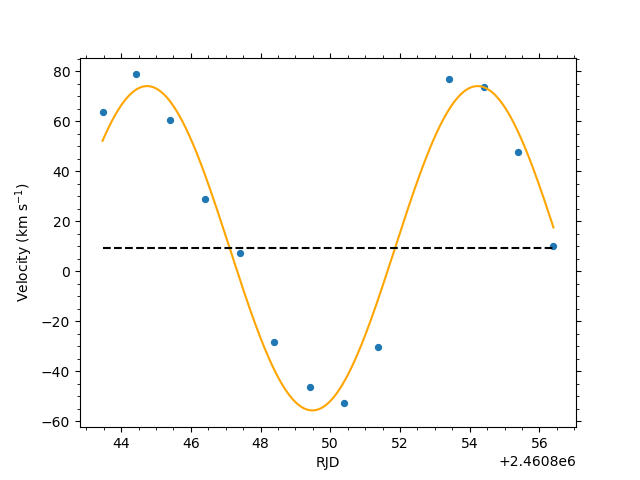

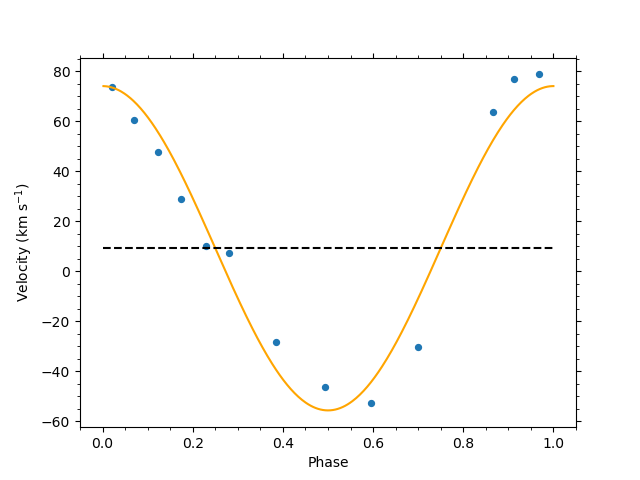

In [72]:
# Lancement du solver
# Essaye d'ajouter de la précision sur Pguess si tu la connais (9.591)
from binarystarsolve import StarSolve
param, err = StarSolve(output_ccf, star="primary", Pguess=9.591, zeroEcc=True, graphs=True)

print(type(params)) # Pour voir si c'est une liste ou un dictionnaire
print(params)       # Pour voir l'ordre des valeurs

gamma_val = params[0]
k_val = params[1]
e_val = params[2]

print(f"Gamma : {gamma_val:.2f} km/s")
print(f"K     : {k_val:.2f} km/s")
print(f"e     : {e_val:.3f}")

Tentative de fit...
Finding initial guesses...
Minimizing...


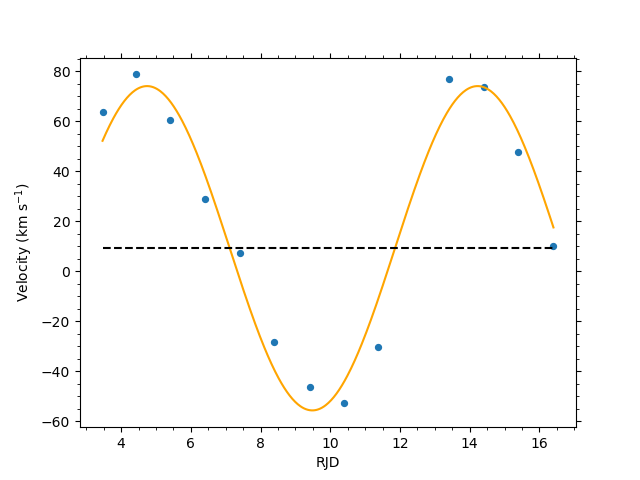

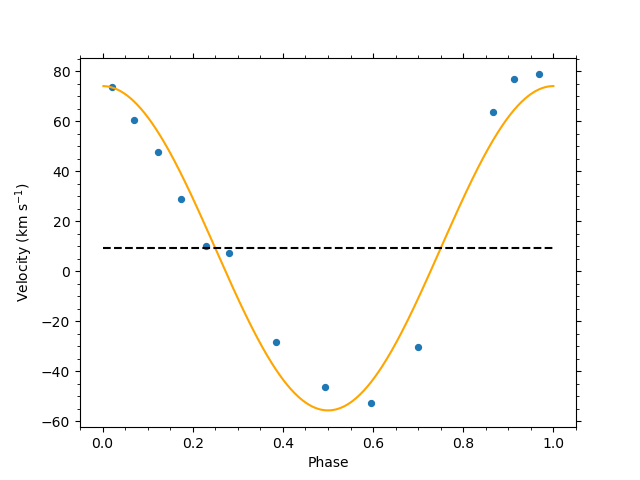

In [73]:
data_ccf = np.array([
    [3.468, 63.77], [4.434, 78.74], [5.403, 60.38], [6.402, 28.93],
    [7.402, 7.26], [8.397, -28.22], [9.414, -46.42], [10.399, -52.55],
    [11.377, -30.34], [13.406, 77.03], [14.423, 73.76], [15.391, 47.85],
    [16.401, 10.00]
])

# Sauvegarde en format standard (float simple)
df = pd.DataFrame(data_ccf)
df.to_csv('ccf_final.txt', sep='\t', index=False, header=False, float_format='%.4f')

# Tentative avec zeroEcc=True pour éviter le crash de la SVD
# Si l'excentricité pose problème, on la fixe à 0 pour stabiliser le premier fit
try:
    print("Tentative de fit...")
    params, err = StarSolve('ccf_final.txt', 
                            star="primary", 
                            Pguess=9.59, 
                            zeroEcc=True, # On force circulaire pour éviter le crash
                            graphs=True)
except Exception as e:
    print(f"Erreur rencontrée : {e}")

In [74]:
from binarystarsolve import StarSolve
#StarSolve(output_ccf)

param, err = StarSolve(output_ccf, star = "both", Pguess = 9.6, zeroEcc = False, graphs = True) 


IndexError: index 2 is out of bounds for axis 1 with size 2

In [75]:


# Generate a fine phase grid for smooth curve
P = param[5]  # Orbital period
T0 = param[4]  # Time of periastron
phase = (time - T0) % P / P

# Sort by phase for plotting
sorted_idx = np.argsort(phase)
phase_sorted = phase[sorted_idx]
rv_sorted = rv[sorted_idx]

plt.figure()
plt.scatter(phase_sorted, rv_sorted, label="Data")
# Overlay best-fit model (you may need to compute model RVs using the params)
plt.xlabel("Orbital Phase")
plt.ylabel("Radial Velocity (km/s)")
plt.legend()
plt.title("RV Curve vs. Phase")
plt.show()

NameError: name 'time' is not defined

In [75]:
param[1]

array([2.79535534e+00, 5.28140000e+01, 1.80000000e+02, 0.00000000e+00,
       2.46085000e+06, 9.60000000e+00, 6.97190000e+00, 1.50140000e-01])